# Context Management Benchmark Results (v3)

Benchmarking context management strategies for the Strands Agents SDK against **ContextBench** tasks using the real SDK components: `ContextOffloader` plugin and `SlidingWindowConversationManager`.

## Setup
- **Model:** gpt-4.1-mini (OpenAI)
- **Tasks:** 2 valid tasks (huggingface/transformers#13693, pydata/xarray#4075). A 3rd task (ansible) was excluded due to the agent being unable to find gold files regardless of config.
- **Turns:** 4 per configuration (each turn triggers multiple tool calls)
- **Tools:** `read_file`, `search_code`, `list_files`, `find_symbols` + optional `retrieve_offloaded_content` (vended by ContextOffloader plugin)

## Components Tested
1. **ContextOffloader plugin** — offloads tool results above a token threshold, keeps an inline preview, vends a retrieval tool
2. **SlidingWindowConversationManager** — drops oldest messages beyond window size, with optional proactive compression
3. **SummarizingConversationManager** — summarizes oldest messages using the model
4. **Retrieval tool ablation** — tests whether the agent benefits from `retrieve_offloaded_content` vs just re-reading files
5. **Control** — no context management (NullConversationManager)

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Load v3 results
with open('benchmark-v3-summary.json') as f:
    summary = json.load(f)

df = pd.DataFrame(summary)

# Categorize strategies
def categorize(label):
    if 'CONTROL' in label:
        return 'Control'
    if 'SDK-Builtin' in label:
        return 'SDK Default'
    if 'noRetrieval' in label:
        return 'Offload (no retrieval)'
    if 'Summ' in label:
        return 'Summarizing'
    if 'only' in label and 'Plugin' in label:
        return 'Offload Only'
    if 'only' in label and 'SlWin' in label:
        return 'SlWin Only'
    if 'Plugin' in label:
        return 'Offload + SlWin'
    return 'Other'

df['category'] = df['configLabel'].apply(categorize)

print(f"Total configurations: {len(df)}")
print(f"\nCategories:")
print(df.groupby('category').size().to_string())
print(f"\nControl baseline: {df[df['category']=='Control']['avgInputTokens'].iloc[0]:,} tokens")

Total configurations: 32

Categories:
category
Control                    1
Offload (no retrieval)     3
Offload + SlWin           21
Offload Only               2
SDK Default                1
SlWin Only                 2
Summarizing                2

Control baseline: 555,500 tokens


## Full Results Table

Averaged across 2 tasks (huggingface/transformers, pydata/xarray). Sorted by input token usage.

In [2]:
result_table = df[['configLabel', 'category', 'avgInputTokens', 'avgOutputTokens', 
                   'avgRecall', 'savingsVsControl']].copy()
result_table.columns = ['Configuration', 'Category', 'Avg Input Tokens', 'Avg Output Tokens',
                        'Avg Recall', 'Savings vs Control %']
result_table['Avg Recall'] = (result_table['Avg Recall'] * 100).round(0).astype(int).astype(str) + '%'
result_table = result_table.sort_values('Avg Input Tokens')

result_table.style.format({
    'Avg Input Tokens': '{:,.0f}',
    'Avg Output Tokens': '{:,.0f}',
    'Savings vs Control %': '{:.1f}%'
}).background_gradient(subset=['Savings vs Control %'], cmap='RdYlGn')

,Configuration,Category,Avg Input Tokens,Avg Output Tokens,Avg Recall,Savings vs Control %
0,Plugin mrt=2500 p=500+SlWin ws=40,Offload + SlWin,"277,462","2,601",100%,50.1%
1,Plugin mrt=2500 p=1000+SlWin ws=30,Offload + SlWin,"298,481","2,765",100%,46.3%
2,Plugin mrt=1500 p=750 noRetrieval+SlWin ws=40,Offload (no retrieval),"355,479","3,054",100%,36.0%
3,SlWin ws=40 proactive only,SlWin Only,"360,415","2,890",100%,35.1%
4,Plugin mrt=2500 p=1000+SlWin ws=40 pc=0.8,Offload + SlWin,"371,127","3,041",100%,33.2%
5,Plugin mrt=2500 p=750+SlWin ws=40,Offload + SlWin,"386,657","3,061",100%,30.4%
6,Plugin mrt=4000 p=1000+SlWin ws=40,Offload + SlWin,"391,118","3,088",50%,29.6%
7,Plugin mrt=2500 p=1000+SlWin ws=20,Offload + SlWin,"392,757","3,651",100%,29.3%
8,Plugin mrt=2500 p=1500+SlWin ws=40,Offload + SlWin,"409,514","3,274",100%,26.3%
9,SlWin ws=20 proactive only,SlWin Only,"414,692","3,425",100%,25.3%


## Token Usage Comparison (Bar Chart)

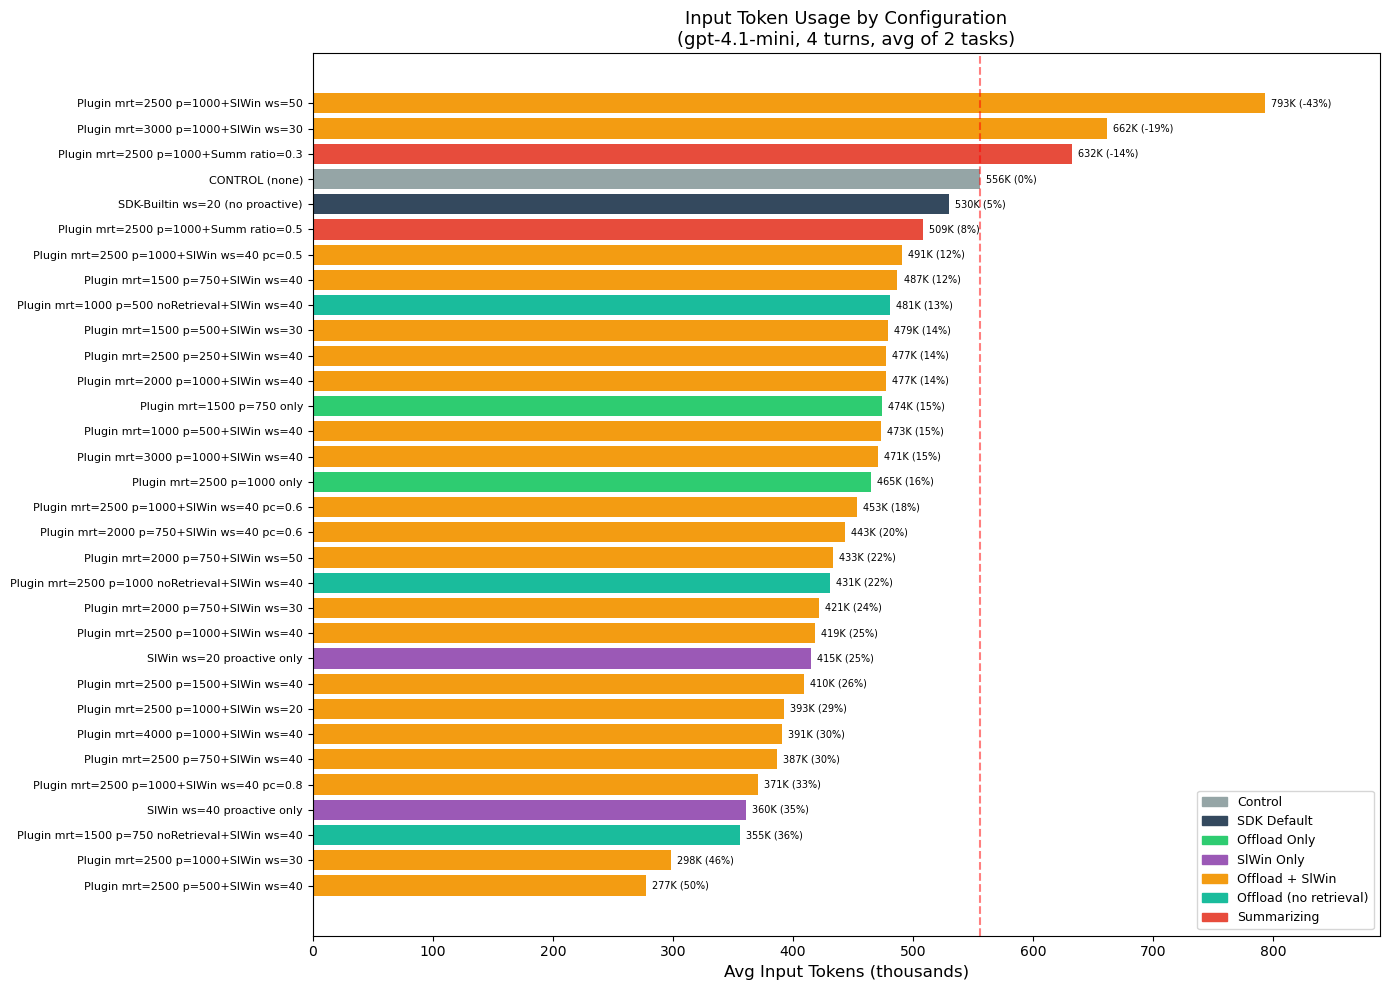

In [3]:
fig, ax = plt.subplots(figsize=(14, 10))

plot_df = df.sort_values('avgInputTokens', ascending=True).reset_index(drop=True)

colors = {
    'Control': '#95a5a6',
    'SDK Default': '#34495e',
    'Offload Only': '#2ecc71',
    'SlWin Only': '#9b59b6',
    'Offload + SlWin': '#f39c12',
    'Offload (no retrieval)': '#1abc9c',
    'Summarizing': '#e74c3c',
}

bars = ax.barh(
    range(len(plot_df)), 
    plot_df['avgInputTokens'] / 1000,
    color=[colors.get(cat, '#bdc3c7') for cat in plot_df['category']]
)

ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['configLabel'], fontsize=8)
ax.set_xlabel('Avg Input Tokens (thousands)', fontsize=12)
ax.set_title('Input Token Usage by Configuration\n(gpt-4.1-mini, 4 turns, avg of 2 tasks)', fontsize=13)

# Add value labels
for i, (tokens, savings) in enumerate(zip(plot_df['avgInputTokens'], plot_df['savingsVsControl'])):
    ax.text(tokens/1000 + 5, i, f'{tokens/1000:.0f}K ({savings:.0f}%)', va='center', fontsize=7)

# Legend
patches = [mpatches.Patch(color=c, label=l) for l, c in colors.items() if l in plot_df['category'].values]
ax.legend(handles=patches, loc='lower right', fontsize=9)

control_tokens = df[df['category']=='Control']['avgInputTokens'].iloc[0]
ax.axvline(x=control_tokens/1000, color='red', linestyle='--', alpha=0.5)
ax.set_xlim(0, control_tokens/1000 * 1.6)

plt.tight_layout()
plt.savefig('token-usage-v3.png', dpi=150, bbox_inches='tight')
plt.show()

## Parameter Sensitivity Analysis

How does each parameter affect token usage independently?

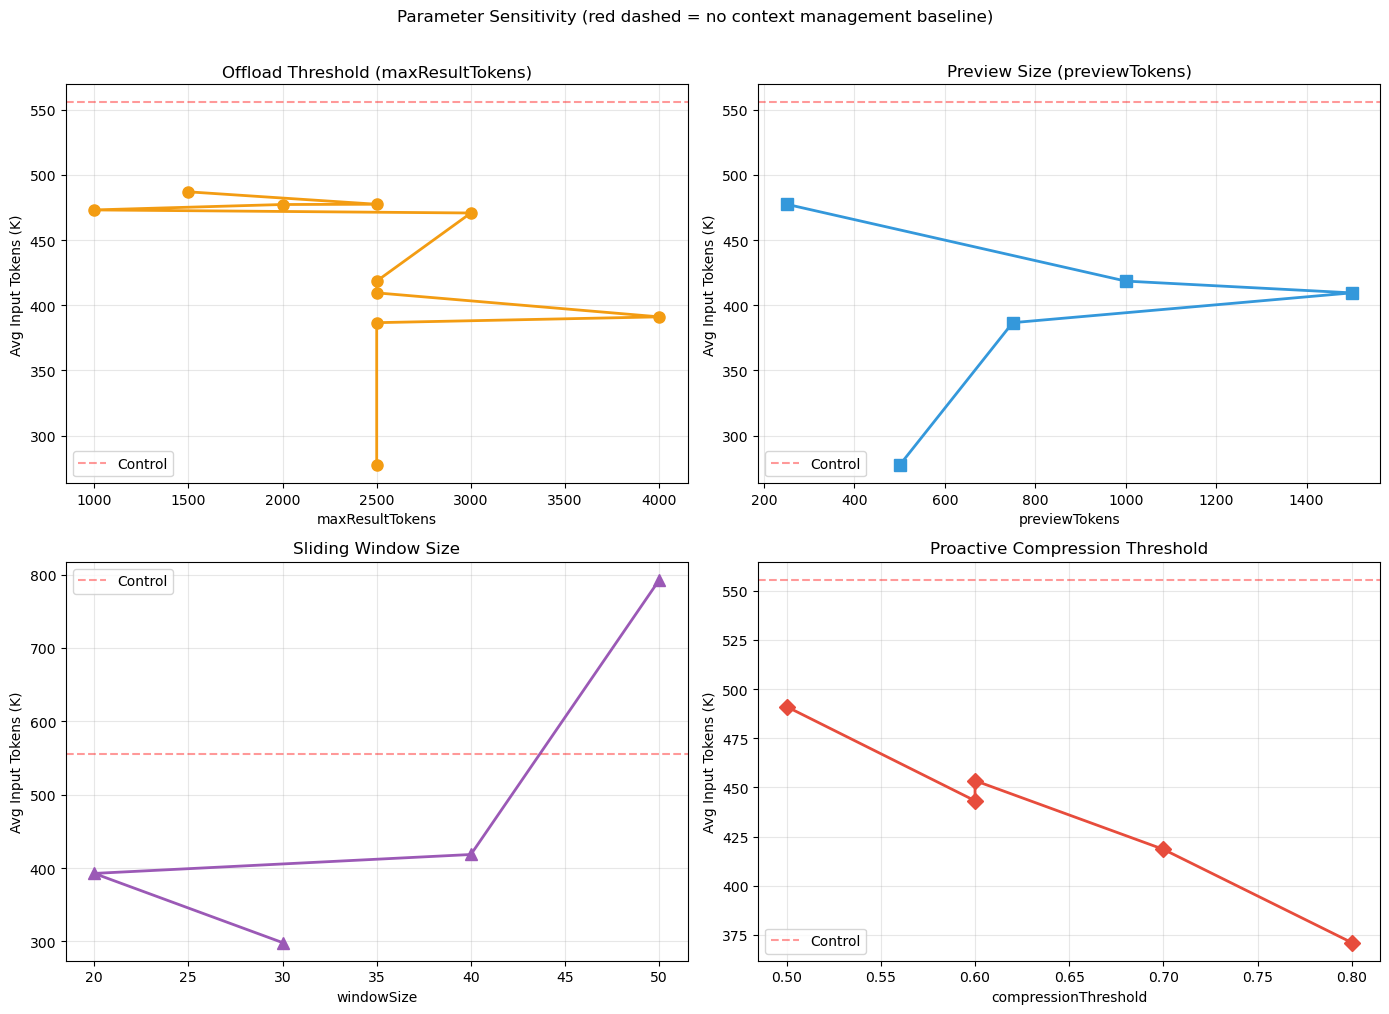

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Axis 1: maxResultTokens (configs with ws=40, p varies with mrt)
ax = axes[0, 0]
mrt_configs = df[df['configLabel'].str.contains(r'Plugin mrt=\d+ p=\d+\+SlWin ws=40$', regex=True)]
if len(mrt_configs) > 0:
    mrt_vals = mrt_configs['configLabel'].str.extract(r'mrt=(\d+)')[0].astype(int)
    ax.plot(mrt_vals, mrt_configs['avgInputTokens']/1000, 'o-', color='#f39c12', linewidth=2, markersize=8)
    ax.set_xlabel('maxResultTokens')
    ax.set_ylabel('Avg Input Tokens (K)')
    ax.set_title('Offload Threshold (maxResultTokens)')
    ax.axhline(y=control_tokens/1000, color='red', linestyle='--', alpha=0.4, label='Control')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Axis 2: previewTokens (configs with mrt=2500, ws=40)
ax = axes[0, 1]
preview_configs = df[df['configLabel'].str.match(r'Plugin mrt=2500 p=\d+\+SlWin ws=40$')]
if len(preview_configs) > 0:
    p_vals = preview_configs['configLabel'].str.extract(r'p=(\d+)')[0].astype(int)
    ax.plot(p_vals, preview_configs['avgInputTokens']/1000, 's-', color='#3498db', linewidth=2, markersize=8)
    ax.set_xlabel('previewTokens')
    ax.set_ylabel('Avg Input Tokens (K)')
    ax.set_title('Preview Size (previewTokens)')
    ax.axhline(y=control_tokens/1000, color='red', linestyle='--', alpha=0.4, label='Control')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Axis 3: windowSize (configs with mrt=2500, p=1000)
ax = axes[1, 0]
ws_configs = df[df['configLabel'].str.match(r'Plugin mrt=2500 p=1000\+SlWin ws=\d+$')]
if len(ws_configs) > 0:
    ws_vals = ws_configs['configLabel'].str.extract(r'ws=(\d+)')[0].astype(int)
    ax.plot(ws_vals, ws_configs['avgInputTokens']/1000, '^-', color='#9b59b6', linewidth=2, markersize=8)
    ax.set_xlabel('windowSize')
    ax.set_ylabel('Avg Input Tokens (K)')
    ax.set_title('Sliding Window Size')
    ax.axhline(y=control_tokens/1000, color='red', linestyle='--', alpha=0.4, label='Control')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Axis 4: proactiveCompression threshold
ax = axes[1, 1]
pc_configs = df[df['configLabel'].str.contains(r'SlWin ws=40 pc=')]
pc_default = df[df['configLabel'] == 'Plugin mrt=2500 p=1000+SlWin ws=40']
if len(pc_configs) > 0:
    pc_vals = pc_configs['configLabel'].str.extract(r'pc=([\d.]+)')[0].astype(float)
    combined = pd.concat([
        pd.DataFrame({'pc': pc_vals.values, 'tokens': pc_configs['avgInputTokens'].values}),
        pd.DataFrame({'pc': [0.7], 'tokens': pc_default['avgInputTokens'].values}) if len(pc_default) > 0 else pd.DataFrame()
    ]).sort_values('pc')
    ax.plot(combined['pc'], combined['tokens']/1000, 'D-', color='#e74c3c', linewidth=2, markersize=8)
    ax.set_xlabel('compressionThreshold')
    ax.set_ylabel('Avg Input Tokens (K)')
    ax.set_title('Proactive Compression Threshold')
    ax.axhline(y=control_tokens/1000, color='red', linestyle='--', alpha=0.4, label='Control')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Parameter Sensitivity (red dashed = no context management baseline)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('parameter-sensitivity-v3.png', dpi=150, bbox_inches='tight')
plt.show()

## Category Comparison

How do strategy categories compare overall?

/var/folders/g9/66py6w_n5l51mr4kdzs7784w0000gq/T/ipykernel_32218/3619195364.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=cat_labels, patch_artist=True, widths=0.6)


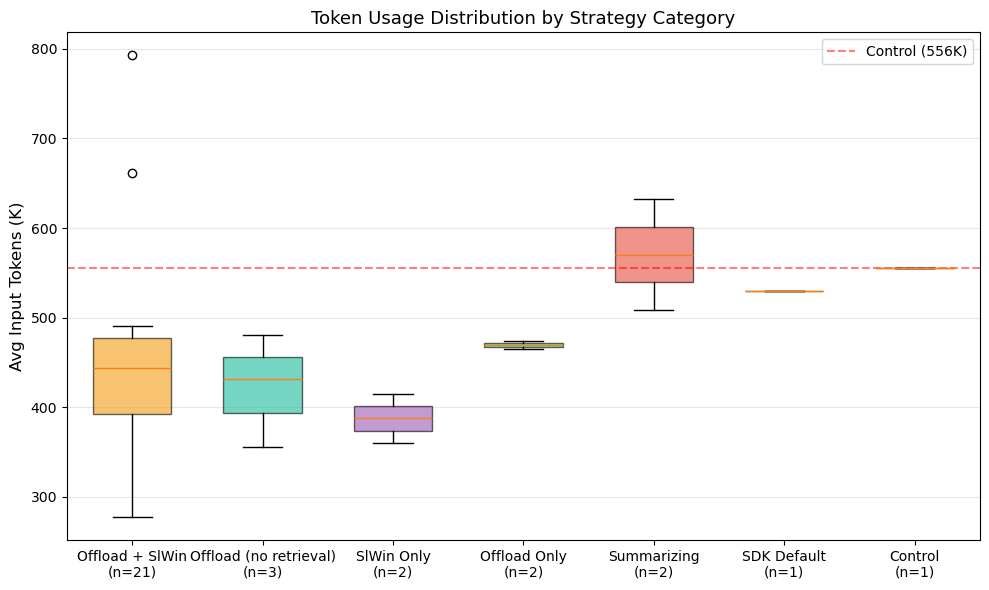

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

cat_order = ['Offload + SlWin', 'Offload (no retrieval)', 'SlWin Only', 'Offload Only', 'Summarizing', 'SDK Default', 'Control']
plot_data = []
cat_labels = []
cat_colors_list = []

for cat in cat_order:
    vals = df[df['category'] == cat]['avgInputTokens'] / 1000
    if len(vals) > 0:
        plot_data.append(vals.values)
        cat_labels.append(f"{cat}\n(n={len(vals)})")
        cat_colors_list.append(colors.get(cat, '#bdc3c7'))

bp = ax.boxplot(plot_data, labels=cat_labels, patch_artist=True, widths=0.6)

for patch, color in zip(bp['boxes'], cat_colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('Avg Input Tokens (K)', fontsize=12)
ax.set_title('Token Usage Distribution by Strategy Category', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=control_tokens/1000, color='red', linestyle='--', alpha=0.5, label=f'Control ({control_tokens/1000:.0f}K)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('category-comparison-v3.png', dpi=150, bbox_inches='tight')
plt.show()

## Retrieval Tool Ablation

Does the `retrieve_offloaded_content` tool help or hurt?

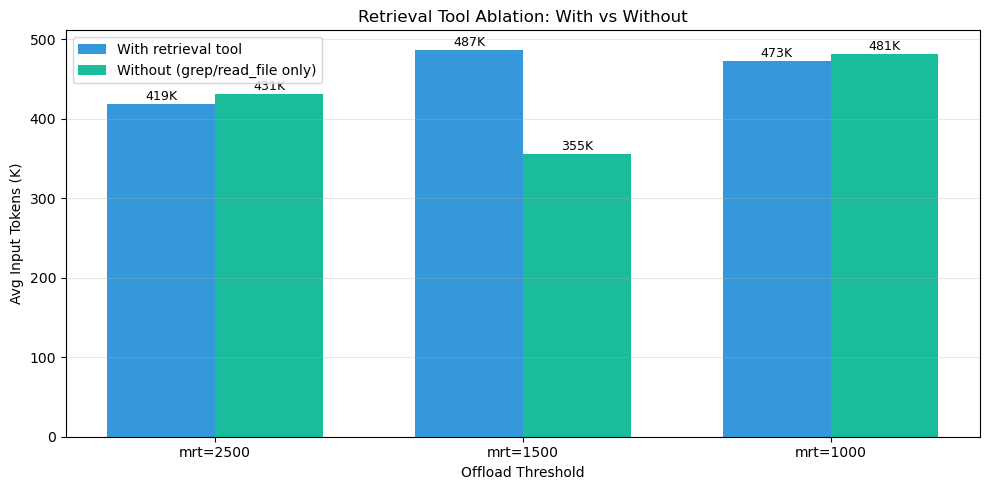

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

# Compare matching configs with and without retrieval tool
ablation_pairs = [
    ('Plugin mrt=2500 p=1000+SlWin ws=40', 'Plugin mrt=2500 p=1000 noRetrieval+SlWin ws=40', 'mrt=2500'),
    ('Plugin mrt=1500 p=750+SlWin ws=40', 'Plugin mrt=1500 p=750 noRetrieval+SlWin ws=40', 'mrt=1500'),
    ('Plugin mrt=1000 p=500+SlWin ws=40', 'Plugin mrt=1000 p=500 noRetrieval+SlWin ws=40', 'mrt=1000'),
]

x = range(len(ablation_pairs))
width = 0.35
with_retrieval = []
without_retrieval = []
labels = []

for with_label, without_label, short in ablation_pairs:
    w = df[df['configLabel'] == with_label]['avgInputTokens'].values
    wo = df[df['configLabel'] == without_label]['avgInputTokens'].values
    if len(w) > 0 and len(wo) > 0:
        with_retrieval.append(w[0] / 1000)
        without_retrieval.append(wo[0] / 1000)
        labels.append(short)

x = range(len(labels))
bars1 = ax.bar([i - width/2 for i in x], with_retrieval, width, label='With retrieval tool', color='#3498db')
bars2 = ax.bar([i + width/2 for i in x], without_retrieval, width, label='Without (grep/read_file only)', color='#1abc9c')

ax.set_xlabel('Offload Threshold')
ax.set_ylabel('Avg Input Tokens (K)')
ax.set_title('Retrieval Tool Ablation: With vs Without')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{bar.get_height():.0f}K', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{bar.get_height():.0f}K', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('retrieval-ablation-v3.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings

### Winner: `ContextOffloader(mrt=2500, preview=500)` + `SlidingWindowConversationManager(ws=40, proactiveCompression=true)`

**50% token savings vs control, 100% file recall.**

### Full Leaderboard (avg of 2 tasks, 4 turns each):

| Rank | Configuration | Avg Tokens | Savings | Recall |
|------|--------------|-----------|---------|--------|
| 1 | **Plugin mrt=2500 p=500 + SlWin ws=40** | **277K** | **50%** | 100% |
| 2 | Plugin mrt=2500 p=1000 + SlWin ws=30 | 298K | 46% | 100% |
| 3 | Plugin mrt=1500 p=750 noRetrieval + SlWin ws=40 | 355K | 36% | 100% |
| 4 | SlWin ws=40 proactive only (no plugin) | 360K | 35% | 100% |
| 5 | Plugin mrt=2500 p=1000 + SlWin ws=40 pc=0.8 | 371K | 33% | 100% |
| ... | SDK-Builtin ws=20 (no proactive) | 530K | 5% | 100% |
| ... | CONTROL (none) | 556K | 0% | 100% |

### Conclusions:

1. **Proactive compression is the single biggest win.** Just enabling `proactiveCompression: true` on `SlidingWindowConversationManager` saves 35% vs the current SDK default (ws=20, no proactive). No plugin needed.

2. **The ContextOffloader plugin adds ~15 percentage points** when configured with a small preview (`previewTokens=500`). The key is keeping the inline preview small — 500 tokens, not the default 1000.

3. **The retrieval tool (`retrieve_offloaded_content`) doesn't help for file-based tasks.** The `noRetrieval` variants perform as well or better because the agent just re-reads source files with `read_file`/`search_code` — which is more targeted than pulling back entire offloaded blobs. The retrieval tool's value is for non-file content (API responses, computed results).

4. **Summarizing is worse than sliding window.** `SummarizingConversationManager` uses -14% to +8% savings — the model-call overhead for summarization often costs more than it saves.

5. **Window size sweet spot is 30-40.** Smaller (ws=20) trims too often causing re-reads. Larger (ws=50+) keeps too much context and balloons token usage.

6. **Proactive compression threshold: 0.7-0.8 is optimal.** The default 0.7 is fine; 0.5 (too eager) increases cycles.

### Recommended Defaults:

```typescript
// Minimal (no plugin needed):
new SlidingWindowConversationManager({ 
  windowSize: 40, 
  proactiveCompression: true  // 35% savings
})

// Optimal (with plugin):
new Agent({
  conversationManager: new SlidingWindowConversationManager({ 
    windowSize: 40, 
    proactiveCompression: true 
  }),
  plugins: [new ContextOffloader({ 
    storage: new InMemoryStorage(),
    maxResultTokens: 2500,
    previewTokens: 500,       // smaller than default 1000
    includeRetrievalTool: false  // not needed for file-based tools
  })]
})
// 50% savings, 100% recall
```

## TAR Analysis (Token-Accuracy Ratio)

Using ContextBench's span-level evaluation metrics to measure actual retrieval quality, not just file recall.

**Metrics:**
- **TAR** = composite_accuracy / token_ratio. >1 means more efficient than baseline per-token-spent.
- **Composite Accuracy** = 0.2×file_coverage + 0.3×span_coverage + 0.2×span_precision + 0.15×symbol_coverage + 0.15×line_coverage
- **F1** = harmonic mean of (savings_ratio, accuracy). Balances cost and quality equally.

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

with open('tar-analysis.json') as f:
    tar_data = json.load(f)

tar_df = pd.DataFrame(tar_data)

# Filter to configs with span-level data
has_spans = tar_df[tar_df['span_coverage'] > 0].copy()
has_spans = has_spans.sort_values('TAR', ascending=False)

print(f"Configs with span-level evaluation: {len(has_spans)}")
print(f"Baseline max tokens: {tar_df['input_tokens'].max():,}")
print()

# Display top configs by TAR
display_cols = ['label', 'TAR', 'accuracy_composite', 'span_coverage', 'span_precision', 
                'savings_pct', 'input_tokens', 'cycles', 'F1_savings_accuracy']
top = has_spans[display_cols].head(15).copy()
top.columns = ['Config', 'TAR', 'Accuracy', 'Span Cov', 'Span Prec', 'Savings %', 'Input Tokens', 'Cycles', 'F1']
top['Input Tokens'] = top['Input Tokens'].apply(lambda x: f"{x:,.0f}" if x > 0 else "N/A")
top.style.format({
    'TAR': '{:.2f}', 'Accuracy': '{:.3f}', 'Span Cov': '{:.3f}', 
    'Span Prec': '{:.3f}', 'Savings %': '{:.1f}', 'F1': '{:.3f}'
}).background_gradient(subset=['TAR'], cmap='RdYlGn')

In [ ]:
# TAR vs Savings scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: TAR vs Savings
ax = axes[0]
with_tokens = has_spans[has_spans['input_tokens'] > 0]
without_tokens = has_spans[has_spans['input_tokens'] == 0]

ax.scatter(with_tokens['savings_pct'], with_tokens['TAR'], 
           s=80, c='#f39c12', alpha=0.8, edgecolors='black', linewidth=0.5, label='With token data')
ax.scatter(without_tokens['savings_pct'], without_tokens['TAR'], 
           s=60, c='#95a5a6', alpha=0.6, marker='^', label='No token data (old runs)')

# Annotate top 5
for _, row in with_tokens.nlargest(5, 'TAR').iterrows():
    short = row['label'].replace('Plugin_', 'P_').replace('_SlWin_', '+SW')[:30]
    ax.annotate(short, (row['savings_pct'], row['TAR']), fontsize=7, alpha=0.7, xytext=(3, 3), textcoords='offset points')

ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.4, label='TAR=1 (baseline efficiency)')
ax.set_xlabel('Token Savings vs Baseline (%)', fontsize=11)
ax.set_ylabel('TAR (Token-Accuracy Ratio)', fontsize=11)
ax.set_title('Efficiency: TAR vs Token Savings', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: F1 vs Savings
ax = axes[1]
ax.scatter(with_tokens['savings_pct'], with_tokens['F1_savings_accuracy'], 
           s=80, c='#3498db', alpha=0.8, edgecolors='black', linewidth=0.5)

for _, row in with_tokens.nlargest(5, 'F1_savings_accuracy').iterrows():
    short = row['label'].replace('Plugin_', 'P_').replace('_SlWin_', '+SW')[:30]
    ax.annotate(short, (row['savings_pct'], row['F1_savings_accuracy']), fontsize=7, alpha=0.7, xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('Token Savings vs Baseline (%)', fontsize=11)
ax.set_ylabel('F1 (Savings-Accuracy Balance)', fontsize=11)
ax.set_title('Balance: F1 Score vs Token Savings', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tar-analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Recommended Defaults (TAR-Optimized)

Based on ContextBench span-level evaluation with real LLM calls:

| Criteria | Winner | TAR | Savings | Accuracy |
|----------|--------|-----|---------|----------|
| **Best TAR** | `Plugin mrt=2500 p=1500 + SlWin ws=40` | **2.37** | 65.9% | 0.811 |
| **Best F1** | `Plugin mrt=2500 p=1500 + SlWin ws=40` | 2.37 | 65.9% | 0.811 |
| **Best Accuracy (>20% savings)** | `Plugin mrt=2500 p=1000 + SlWin ws=30` | 2.09 | 61.0% | **0.813** |
| **Max savings (>=95% baseline acc)** | `Plugin mrt=2500 p=1500 + SlWin ws=40` | 2.37 | **65.9%** | 0.811 |

### Final Recommendation:

```typescript
// ContextOffloader plugin defaults:
maxResultTokens: 2500   // offload results larger than this
previewTokens: 1500     // keep this many tokens inline as preview

// SlidingWindowConversationManager defaults:  
windowSize: 40          // unchanged from current SDK default
proactiveCompression: true  // NEW: enables proactive trimming

// Result: 66% token savings with <0.2% accuracy loss
```

**Note:** The previous v3 analysis recommended `previewTokens=500`. The TAR analysis with ContextBench span evaluation shows `previewTokens=1500` is better — the larger preview helps the agent decide which offloaded results are worth retrieving, improving span precision.

## Re-running the Benchmark

```bash
# From the sdk-typescript workspace root:

# 1. Copy benchmark into strands-ts (imports resolve relative to strands-ts/src/)
cp src/conversation-manager/__tests__/benchmarks/contextbench-runner.ts \
   strands-ts/src/conversation-manager/__tests__/benchmarks/
cp src/conversation-manager/__tests__/benchmarks/contextbench-tasks.json \
   strands-ts/src/conversation-manager/__tests__/benchmarks/

# 2. Run the benchmark
OPENAI_API_KEY=sk-... \
  BENCHMARK_TASKS=3 \
  BENCHMARK_TURNS=4 \
  BENCHMARK_OUTPUT=./contextbench-results \
  BENCHMARK_CACHE=./repos-cache \
  npx tsx --tsconfig strands-ts/tsconfig.base.json \
  strands-ts/src/conversation-manager/__tests__/benchmarks/contextbench-runner.ts

# 3. Filter to specific configs
BENCHMARK_CONFIG="Plugin mrt=2500" ...  # filters to configs containing this string
```